<a href="https://colab.research.google.com/github/Serge3leo/temp-cola/blob/main/valq/260325/ecosw_sin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from math import *
import os
import sys

import numpy as np
import scipy
import matplotlib.pyplot as plt
import tqdm

# %matplotlib osx
%config InlineBackend.figure_format = "retina"

In [2]:
# Хм, а скопировать что-ли? Пока, ячейка с `lss_error` на colab 
# работать не будет, надо будет пропускать руками
hdr_add_modules = os.environ['HOME'] + '/soft/valq/modules'

if hdr_add_modules not in sys.path:
    assert 'hdr_save_sys_path' not in globals(), \
            "hdr_add_modules нельзя удалять из sys.path"
    hdr_save_sys_path = sys.path.copy()
    sys.path.insert(1, hdr_add_modules)
elif hdr_add_modules in sys.path:
    print('hdr_add_modules уже есть в sys.path')
else:
    assert False, "Ошибка, однако"

In [3]:
import lss_error
# np.int = np.int64  # dfogn workaround
# lss_error.do_test()  # verbose=True)

# Входные данные

```
 "ecosw""sigmaecosw"   "jdh""sigmajdh"
...
система уравнений : e*cos(w0+(jdh-jdh0)*dw)  c ошибками ecos и jdh
```

In [4]:
ecosw_in = np.loadtxt("ecosw.txt", skiprows=1, usecols=(0,1,2,3),
                      max_rows=7)
ecosw = ecosw_in  # [(0,3,4,5,6),:] # Если убрать пару точек, то совсем неубедительно
with np.printoptions(precision=6, suppress=True):
    for el in ecosw:
        print(el)
a_ecw = 0
a_ecw_sigma = 1
a_jdh = 2
a_jdh_sigma = 3
jdh0 = ecosw[0, a_jdh]
print(f"{a_ecw, a_jdh, jdh0=}")

[   -0.00061     0.00487 52450.         24.     ]
[    0.00192     0.00308 53900.        470.     ]
[    0.00723     0.00498 56522.        189.     ]
[    0.00566     0.0044  57920.         10.     ]
[    0.00492     0.00092 59011.         15.     ]
[    0.00435     0.00097 59753.         10.     ]
[    0.00479     0.00123 60479.         15.     ]
a_ecw, a_jdh, jdh0=(0, 2, 52450.0)


## Учёт ошибок входных данных

В данном случае, взвешивание на $1 / \sigma_{e \cos(\omega)}$ даёт
весьма консервативный результат. Типа надёжно, и без всякого
излишнего оптимизма.

In [5]:
weight = np.ones_like(ecosw[:, a_ecw_sigma])
weight /= ecosw[:, a_ecw_sigma]
weight_txt = "Без весов" if np.all(1. == weight) else "Взвешенное"

# Расчёт невязок и матрицы Якоби

In [6]:
method_id = ('e', 'w0', 'dw')
x_e = 0
x_w0 = 1
x_dw = 2
def ecw_fun_c(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
              jdh0_=jdh0, weight_=weight):
    return ((x[x_e]*np.cos(x[x_w0] + (jdh_ - jdh0_)*x[x_dw]))
            - ecw_) * weight_

def ecw_jac_c(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
              jdh0_=jdh0, weight_=weight):
    jac = np.empty((ecosw.shape[0], len(x)))
    djdh = jdh_ - jdh0_
    jac[:,0] = np.cos(x[x_w0] + djdh*x[x_dw]) * weight_
    jac[:,1] = -x[x_e]*np.sin(x[x_w0] + djdh*x[x_dw]) * weight_
    jac[:,2] = jac[:,1]*djdh
    return jac

In [7]:
def solsq(x0_, bounds_, use_jac=True, ecw_=ecosw[:, a_ecw],
          jdh_=ecosw[:, a_jdh], jdh0_=jdh0, weight_=weight):
    jac = ecw_jac_c if use_jac else '2-point'  # {‘2-point’, ‘3-point’, ‘cs’, callable}, optional
    return scipy.optimize.least_squares(
            ecw_fun_c, x0_, bounds=bounds_,
            kwargs=dict(ecw_=ecw_, jdh_=jdh_, jdh0_=jdh0_,
                        weight_=weight_),
            jac=jac,
            ftol=1e-13, gtol=1e-13)

## Вариант замены переменной
$\omega_0 = \omega_0' - \frac{\pi}{2}$

После замены, графики немного ровнее, но это видно только на большом
масштабе. Т.е. результаты, пока, идентичны. Только расчёт немного
шустрее.

In [8]:
method_id = ('e', "w0'", 'dw')
x_e = 0
x_w0_s = 1
x_dw = 2
def ecw_fun_s(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
              jdh0_=jdh0, weight_=weight):
    return ((x[x_e]*np.sin(x[x_w0_s] + (jdh_ - jdh0_)*x[x_dw]))
            - ecw_) * weight_

def ecw_jac_s(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
              jdh0_=jdh0, weight_=weight):
    jac = np.empty((ecosw.shape[0], len(x)))
    djdh = jdh_ - jdh0_
    jac[:,0] = np.sin(x[x_w0_s] + djdh*x[x_dw]) * weight_
    jac[:,1] = x[x_e]*np.cos(x[x_w0_s] + djdh*x[x_dw]) * weight_
    jac[:,2] = jac[:,1]*djdh
    return jac

In [9]:
def solsq(x0_, bounds_, use_jac=True, ecw_=ecosw[:, a_ecw],
          jdh_=ecosw[:, a_jdh], jdh0_=jdh0, weight_=weight):
    jac = ecw_jac_s if use_jac else '2-point'  # {‘2-point’, ‘3-point’, ‘cs’, callable}, optional
    return scipy.optimize.least_squares(
            ecw_fun_s, x0_, bounds=bounds_,
            kwargs=dict(ecw_=ecw_, jdh_=jdh_, jdh0_=jdh0_,
                        weight_=weight_),
            jac=jac,
            ftol=1e-13, gtol=1e-13)

# Начальная точка
Есть вопросы, но пока так.

In [10]:
x0 = np.array((np.average(ecosw[:, a_ecw]), np.pi/2.-0.001, 0.001))
x0

array([4.03714286e-03, 1.56979633e+00, 1.00000000e-03])

In [11]:
# minres_a.x, minres_a
# minres_b.x, minres_b

In [12]:
x0 = np.array([4.99129963e-03, 4.75366679e+00 - 2*pi, 2.54988863e-04])
x0

array([ 4.99129963e-03, -1.52951852e+00,  2.54988863e-04])

In [13]:
x0 = np.array([4.99129963e-03, 0.04127780961530991, 2.54988863e-04])
x0

array([0.0049913 , 0.04127781, 0.00025499])

In [14]:
z = x0[1] + pi/2
z

1.6120741364102065

In [15]:
x0[1], z - pi/2

(0.04127780961530991, 0.04127780961530991)

# Границы
Первоначально, поиск не уходил с нуля. Пока оставил ненулевые ограничения.

Ограничение $\omega \in [-2 \pi ... 2 \pi]$ , выбрано таковым, что бы 
поиск не упирался в него.

In [16]:
bounds = np.array(((1e-7, -2.*np.pi, -0.1),
                   (0.5, 2.*np.pi, 0.1)))
bounds

array([[ 1.00000000e-07, -6.28318531e+00, -1.00000000e-01],
       [ 5.00000000e-01,  6.28318531e+00,  1.00000000e-01]])

# Поиск и сравнение матриц Якоби

In [17]:
res = solsq(x0, bounds)
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 1.676e-01  2.409e-02 -5.680e-01 -1.623e-01  2.176e-02
                3.790e-01 -3.683e-01]
           x: [ 4.991e-03  4.128e-02  2.550e-04]
        cost: 0.32870510291837063
         jac: [[ 8.474e+00  1.024e+00  0.000e+00]
               [ 1.297e+02  1.486e+00  2.154e+03]
               ...
               [ 9.744e+02 -1.680e+00 -1.227e+04]
               [ 7.064e+02 -2.009e+00 -1.613e+04]]
        grad: [ 5.684e-13  1.092e-10 -2.999e-06]
  optimality: 2.9910867443571046e-07
 active_mask: [0 0 0]
        nfev: 2
        njev: 2

In [18]:
resn = solsq(x0, bounds, use_jac=False)
resn

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 1.676e-01  2.409e-02 -5.680e-01 -1.623e-01  2.176e-02
                3.790e-01 -3.683e-01]
           x: [ 4.991e-03  4.128e-02  2.550e-04]
        cost: 0.3287051029183707
         jac: [[ 8.474e+00  1.024e+00  0.000e+00]
               [ 1.297e+02  1.486e+00  2.154e+03]
               ...
               [ 9.744e+02 -1.680e+00 -1.227e+04]
               [ 7.064e+02 -2.009e+00 -1.613e+04]]
        grad: [ 1.737e-05 -5.922e-08 -4.414e-02]
  optimality: 0.0044031108986687184
 active_mask: [0 0 0]
        nfev: 7
        njev: 1

In [19]:
(resn.jac - ecw_jac_c(resn.x))/ecw_jac_c(resn.x)

/var/folders/wy/z0gbkfgs7mv24ryqkdm90rm40009rh/T/ipykernel_72756/2102961737.py:1: RuntimeWarning: invalid value encountered in divide
  (resn.jac - ecw_jac_c(resn.x))/ecw_jac_c(resn.x)


array([[ -0.95869873, -25.21233082,          nan],
       [ -0.5641655 ,  -3.29444891,  -3.29443811],
       [  0.86938421,  -1.53493549,  -1.53490517],
       [  6.3773187 ,  -1.1355506 ,  -1.13550985],
       [ -7.92253142,  -0.85554417,  -0.85549529],
       [ -3.89431053,  -0.65449456,  -0.65444016],
       [ -2.75553431,  -0.43037285,  -0.43031303]])

Не похоже, что бы была явная лажа в вычислении матрицы Якоби. Более-менее.

In [20]:
np.cos(resn.x[x_w0] + (ecosw[:, a_jdh] - jdh0)*resn.x[x_dw])

array([ 0.99914819,  0.9167171 ,  0.47168776,  0.1343222 , -0.1429718 ,
       -0.32656322, -0.49495849])

In [21]:
np.cos(res.x[x_w0] + (ecosw[:, a_jdh] - jdh0)*res.x[x_dw])

array([ 0.99914819,  0.91671709,  0.47168775,  0.1343222 , -0.1429718 ,
       -0.32656322, -0.4949585 ])

Замечание до замены:
> Три числа около 1 намекают, что стоит попробовать сделать
замену: $\omega_0 = \omega_0' - \frac{\pi}{2}$

# Типа невязки
Пока выглядит всё более менее.  Грубо говоря, сумма квадратов невязок
примерно $0.8 \times \sigma$.  Однако, решения с весами и без весов
заметно различаются:
- взвешенное: `[ 4.991e-03  4.128e-02  2.550e-04]` (`[ 4.991e-03 -1.530e+00  2.550e-04]`)
- без весов: `[ 6.297e-03 -9.100e-02  3.215e-04]` (`[ 6.297e-03 -1.662e+00  3.215e-04]`)

Следует отметить, что графики без взвешивания гораздо более
оптимистичны (практически на порядок), ввиду того, что без взвешивания
вторая и третья точки вносят гораздо больший вклад в невязку.

Взвешенные невязки, в $\sigma$ каждой точки.

In [22]:
res.fun / weight / ecosw[:, a_ecw_sigma]

array([ 0.1675506 ,  0.0240937 , -0.56804085, -0.16225749,  0.02176394,
        0.37902415, -0.36827383])

In [23]:
ecosw[:, a_jdh_sigma]

array([ 24., 470., 189.,  10.,  15.,  10.,  15.])

In [24]:
np.sqrt(np.sum(res.fun**2)), np.sqrt(2.*res.cost)

(0.810808365667709, 0.810808365667709)

Невязки без весов, так сказать, а ля натурель.

In [25]:
res.fun/weight

array([ 8.15971437e-04,  7.42085975e-05, -2.82884344e-03, -7.13932973e-04,
        2.00228208e-05,  3.67653425e-04, -4.52976817e-04])

# Оценка точности решения МНК
По матрице Якоби (статистическая). Статистика, конечно, никакая, да и
минимум неглубокий, в общем, сплошной розовый оптимизм, но... 

In [26]:
err, cov = lss_error.scipyERR(res)
with np.printoptions(precision=5):
    print(err)
    print(cov)
    for i in range(3):
        print(f"{method_id[i]:4} = {res.x[i]: .5f} ± {err[i]:.5f} (1𝜎, 68%)")

[4.24189e-04 2.57615e-01 5.16497e-05]
[[ 1.79936e-07 -1.94457e-05  1.39840e-08]
 [-1.94457e-05  6.63656e-02 -1.03369e-05]
 [ 1.39840e-08 -1.03369e-05  2.66769e-09]]
e    =  0.00499 ± 0.00042 (1𝜎, 68%)
w0'  =  0.04128 ± 0.25762 (1𝜎, 68%)
dw   =  0.00025 ± 0.00005 (1𝜎, 68%)


# Зависимость суммы квадратов невязок от переменных

Разбиваем область значений каждой переменной на интервалы, и решаем
задачу МНК с ограничением в этом интервале.

Т.е. пытаемся таким образом визуализировать доверительные интервалы.

In [27]:
def bound_plot(res_, bounds_, log=True):
    minres = res_
    fig, ax = plt.subplots(3, 3)
    for i in range(3):
        resj = res_
        boundi = bounds_[:, i].copy()
        lowi = np.linspace(boundi[0], boundi[1], num=128)
        costi = np.zeros((len(lowi) - 1,))
        res_xi = np.zeros((len(lowi) - 1, 3))
        for j in range(len(lowi) - 1):
            xj = res.x.copy()  # TODO ???
            boundj = bounds_.copy()
            for k in range(3):
                assert boundj[0, k] < xj[k] and xj[k] < boundj[1, k], \
                    f"{k, boundj[0, k], xj[k], boundj[1, k]=}"
            boundj[0, i] = lowi[j]
            boundj[1, i] = lowi[j + 1]
            xj[i] = np.average(boundj[:, i])
            for k in range(3):
                assert boundj[0, k] < xj[k] and xj[k] < boundj[1, k], \
                    f"{k, boundj[0, k], xj[k], boundj[1, k]=}"
            resj = solsq(xj, boundj)
            costi[j] = resj.cost
            res_xi[j] = resj.x
            if resj.cost < minres.cost:
                minres = resj
        ax[0][i].plot(res_xi[:,i], np.sqrt(2.*costi),
                      label=f"$\\sigma$ of {method_id[i]}")
        if log:
            ax[0][i].set_yscale('log')
        ax[0][i].legend()
        for j in range(3):
            if j != i:
                axji = ax[j + 1 if j < i else j][i]
                axji.plot(res_xi[:,i], res_xi[:,j],
                              label=f"{method_id[j]} of {method_id[i]}")
                axji.legend()
                # axji.set_ylabel(f"{method.id[j]}")
        axji.set_xlabel(f"{method_id[i]}")

    fig.suptitle(f"{weight_txt}")
    return fig, ax, minres

## По всей области значений
Верхний ряд это $\sqrt{\sum{{O-C}^2}}$, в зависимости от
изменения соответствующего параметра.

На графиках нижних двух рядов отображаются найденные значения двух
других параметров (свободных параметров).

1. Эксцентриситет, невязка значительно растёт до $e = 0.055..0.059$,
   однако после, устанавливается на уровне $1.6 \times \sigma$. Т.е.
   решение уравнения, само по себе, не даёт надёжных доказательств,
   что он небольшой.
3. $\omega_0$ определяется хреново;
4. `dw` зависит от остальных параметров.

True

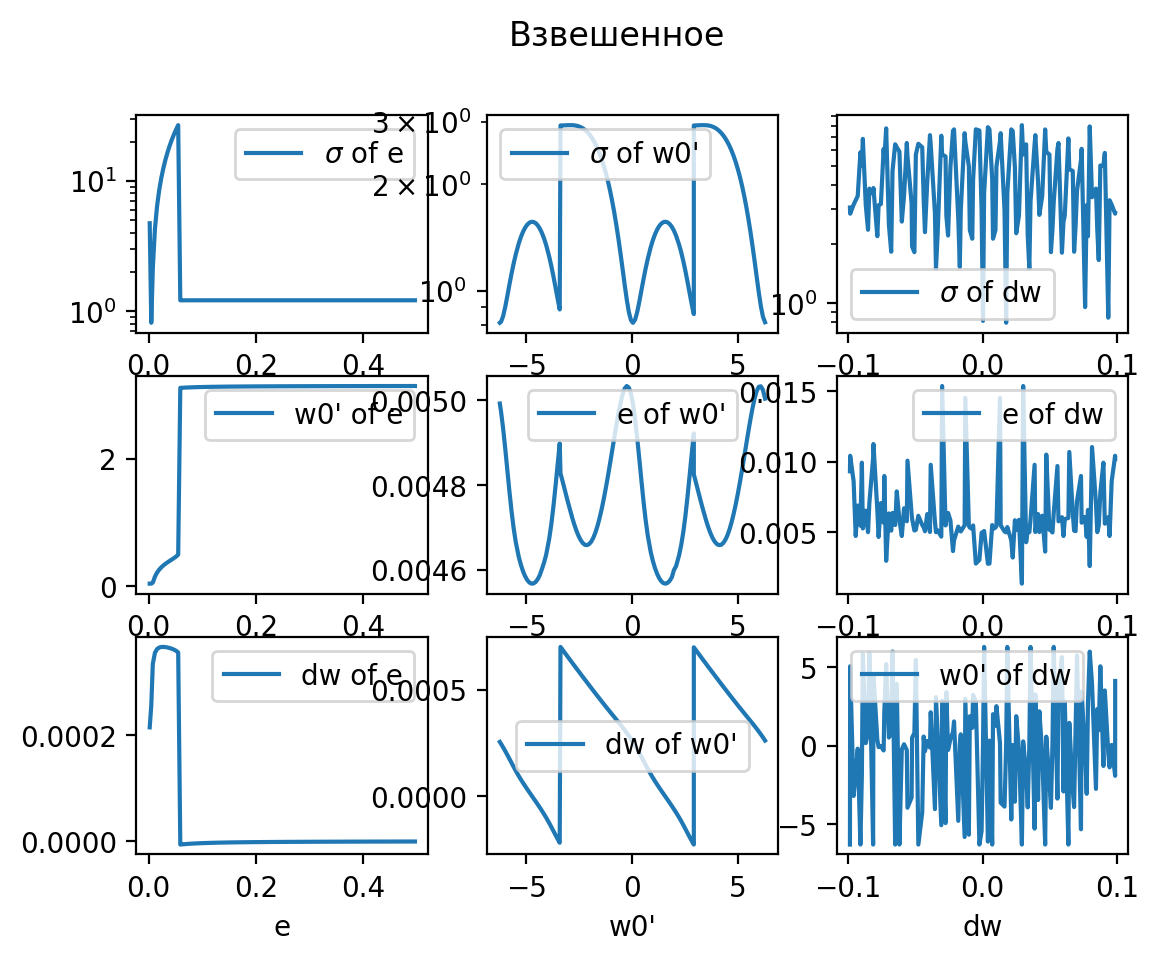

In [28]:
fig, ax, minres_a = bound_plot(res, bounds, log=True)
minres_a.cost < res.cost

In [29]:
bounds_05_10 = bounds.copy()
bounds_05_10[:,0] = [0.5, 1.0]
x0_05_10 = x0.copy()
x0_05_10[0] = 0.75
res_05_10 = solsq(x0_05_10, bounds_05_10)
res_05_10, np.sqrt(2.*res_05_10.cost/len(res_05_10.fun))

(     message: `xtol` termination condition is satisfied.
      success: True
       status: 3
          fun: [ 5.250e-01  1.898e-01 -7.463e-01 -3.656e-01 -4.882e-01
                 4.189e-01  1.997e-01]
            x: [ 5.000e-01  3.138e+00 -7.694e-07]
         cost: 0.7280062283019303
          jac: [[ 7.995e-01 -1.027e+02 -0.000e+00]
                [ 1.626e+00 -1.623e+02 -2.354e+05]
                ...
                [ 9.807e+00 -5.154e+02 -3.764e+06]
                [ 8.188e+00 -4.065e+02 -3.264e+06]]
         grad: [ 2.536e-05  3.596e-10  5.313e-06]
   optimality: 5.312921579296195e-07
  active_mask: [-1  0  0]
         nfev: 20
         njev: 20,
 0.45607212095768057)

## В районе минимума
1. Эксцентриситет, если есть основания полагать, что он небольшой, то
   на уровне $3 \sigma$ он лежит в интервале `0.003...0.009`;
2. $\omega_0$ видны два минимума: `-1.530` и `+1.311`, их глубины
   $0.8 \times \sigma$ и $0.9 \times \sigma$, разделены горбом
   $1.6 \times \sigma$;

True

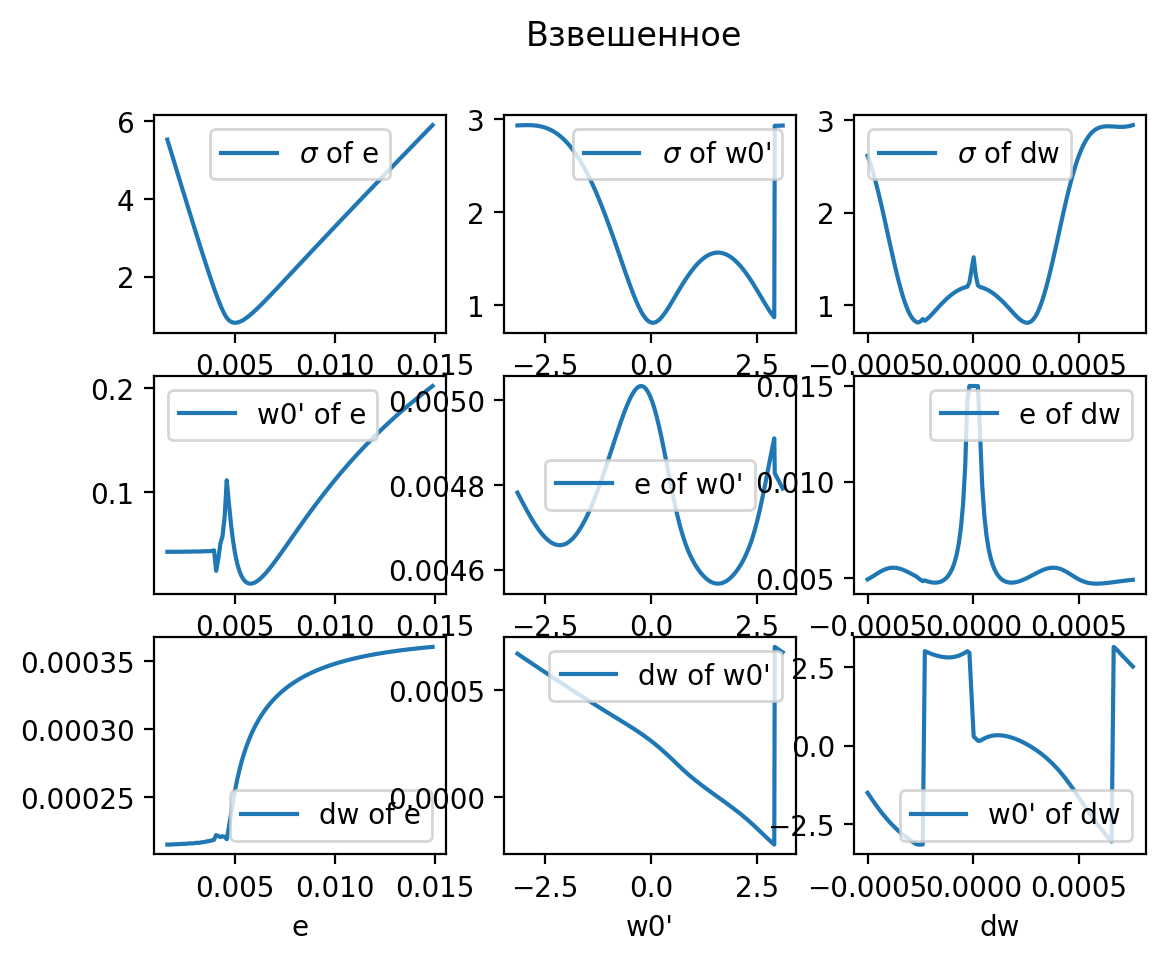

In [30]:
res_bound = np.array((
        (res.x[0] - 0.7*abs(res.x[0]),
         -pi,
         res.x[2] - 3.0*abs(res.x[2])
        ),
        (res.x[0] + 2.0*abs(res.x[0]),
         pi,
         res.x[2] + 2.0*abs(res.x[2])
        )
    ))
fig, ax, minres_b = bound_plot(res, res_bound, log=False)
minres_b.cost < res.cost

# Оценка ошибки методом Монте-Карло

Возмущаем `ecw` и `jdh` согласно `ecw_sigma` и `jdh_sigma`, строим
графики найденных решений и вычисляем матрицу ковариации.

In [31]:
Niter = 1000
ress = np.empty((3, Niter))
for i in tqdm.trange(Niter):
    ecwr = np.random.normal(ecosw[:, a_ecw], ecosw[:, a_ecw_sigma])
    jdhr = np.random.normal(ecosw[:, a_jdh], ecosw[:, a_jdh_sigma])
    resr = solsq(x0, bounds, ecw_=ecwr, jdh_=jdhr)
    ress[:, i] = resr.x

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:27<00:00, 36.37it/s]


In [32]:
cov = np.cov(ress)
err = np.sqrt(np.diag(cov))
with np.printoptions(precision=5, suppress=True):
    print(err)
with np.printoptions(precision=2):
    print(cov)
for i in range(3):
    print(f"{method_id[i]:4} = {res.x[i]: .5f} ± {err[i]:.5f} (1𝜎, 68%)")

[0.11    0.64106 0.00014]
[[ 1.21e-02  9.16e-03 -1.06e-05]
 [ 9.16e-03  4.11e-01 -4.65e-05]
 [-1.06e-05 -4.65e-05  1.99e-08]]
e    =  0.00499 ± 0.11000 (1𝜎, 68%)
w0'  =  0.04128 ± 0.64106 (1𝜎, 68%)
dw   =  0.00025 ± 0.00014 (1𝜎, 68%)


Среднее, по результатам Монте-Карло, отличается, но
в пределах ошибок. Примерно, так и должно быть, мы же возмущаем
входные данные.

In [33]:
with np.printoptions(precision=5, suppress=True):
    avg = np.average(ress, axis=1)
    print(f"{'avg':12} = {avg}")
    print(f"{'avg - res.x':12} = {avg - res.x}")

avg          = [0.05558 0.01555 0.00021]
avg - res.x  = [ 0.05059 -0.02573 -0.00004]


Text(0.5, 0.98, 'N=1000, Взвешенное')

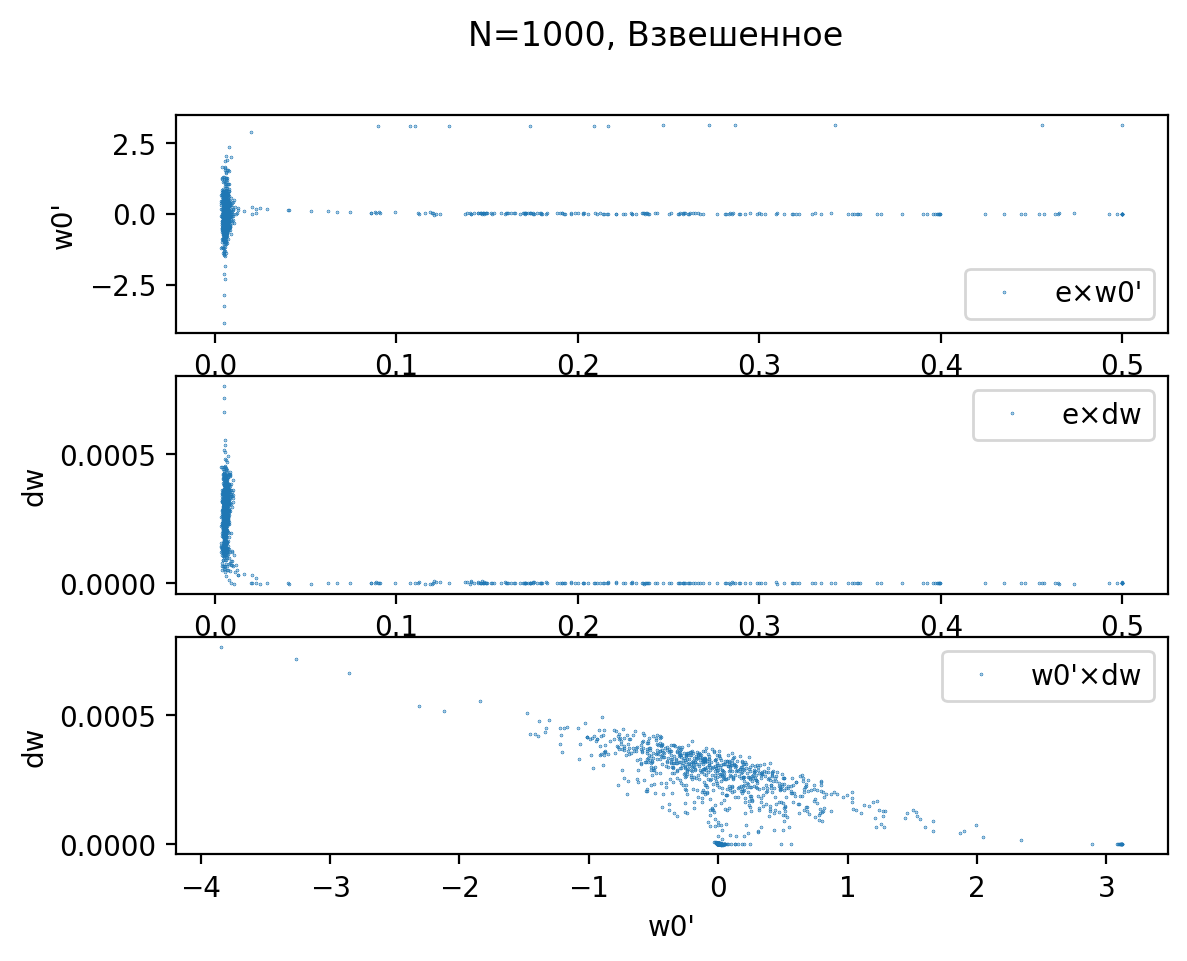

In [34]:
fig, ax = plt.subplots(3)
k = 0
for i in range(2):
    for j in range(i + 1, 3):
        ax[k].plot(ress[i, :], ress[j, :], '.', ms=0.5,
                   label=f"{method_id[i]}×{method_id[j]}")
        ax[k].legend()
        ax[k].set_xlabel(f"{method_id[i]}")
        ax[k].set_ylabel(f"{method_id[j]}")
        k += 1
fig.suptitle(f"N={ress.shape[1]}, {weight_txt}")

# Резюме
Явно гарантированного ответа нет.  Вроде как, видно, что при
определённых сочетаниях $\omega_0$ ($\omega_0'$) и `dw`, данные 
могут быть объяснены при любом `e`.

Более вероятно:
```
e    =  0.00499 ± 0.11331 (1𝜎, 68%)
w0'  =  0.04128 ± 0.77213 (1𝜎, 68%)
w0   = -1.52952
dw   =  0.00025 ± 0.00015 (1𝜎, 68%)
```

In [35]:
f"w0   = {res.x[x_w0_s] - pi/2:.5f}"

'w0   = -1.52952'

Но может быть и:

In [36]:
bounds2 = bounds.copy()
bounds2[0, x_w0_s] = 1.1 + pi/2
bounds2[1, x_w0_s] = 1.35 + pi/2
bounds2[0, x_dw] = -0.1
x02 = x0.copy()
x02[x_w0_s] = 1.2 + pi/2
res2 = solsq(x02, bounds2)
res2, bounds2

(     message: `xtol` termination condition is satisfied.
      success: True
       status: 3
          fun: [ 3.466e-01  2.089e-01 -5.541e-01 -1.753e-01 -4.300e-02
                 3.672e-01 -3.102e-01]
            x: [ 4.922e-03  2.921e+00 -2.255e-04]
         cost: 0.36726062823998173
          jac: [[ 4.497e+01 -9.861e-01 -0.000e+00]
                [ 1.691e+02 -1.364e+00 -1.978e+03]
                ...
                [ 9.858e+02  1.485e+00  1.085e+04]
                [ 7.282e+02  1.779e+00  1.429e+04]]
         grad: [-9.834e-12 -4.112e-01  2.933e-07]
   optimality: 2.926287407864255e-08
  active_mask: [0 1 0]
         nfev: 52
         njev: 46,
 array([[ 1.00000000e-07,  2.67079633e+00, -1.00000000e-01],
        [ 5.00000000e-01,  2.92079633e+00,  1.00000000e-01]]))

In [37]:
for i in range(3):
    print(f"{method_id[i]:4} = {res2.x[i]: .5f} ± {err[i]:.5f} (1𝜎, 68%)")
print(f"{'w0':4} = {res2.x[x_w0_s] - pi/2: .5f}")

e    =  0.00492 ± 0.11000 (1𝜎, 68%)
w0'  =  2.92080 ± 0.64106 (1𝜎, 68%)
dw   = -0.00023 ± 0.00014 (1𝜎, 68%)
w0   =  1.35000
